In [4]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.models import SIRM, SIRT, SIRV
from helps import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
temp = read_json("./parameters.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]

In [9]:
betas = np.linspace(0.15, 0.4, 25)
NB = 50
NP = 50
homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PS = 10
PARAMS["fixed_mean"] = 0.5
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.2, 0.4, 0.6, 0.8]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx/1.25,  # Figure width in inches
        'Ly': Ly/1.25,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 3, 6],
        'xlim': [0, 1],
        'ylim': [0, 6]
    }

In [10]:
betas = [0.15, 0.2, 0.3]
print("### SIR-M ###")
PS = 20
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-T ###")
res_list_T = []

for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-V ###")
res_list_V = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")


### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.2
Completed beta_M = 0.3
### SIR-T ###
Completed beta_M = 0.15
Completed beta_M = 0.2
Completed beta_M = 0.3
### SIR-V ###
Completed beta_M = 0.15
Completed beta_M = 0.2
Completed beta_M = 0.3


min-max range: 0.00039839745  to  0.29076284  -- max variation --  29.0
min-max range: 0.008637071  to  0.39987612  -- max variation --  39.0
min-max range: 0.30847764  to  0.5814961  -- max variation --  27.0


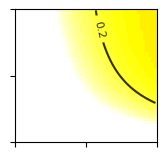

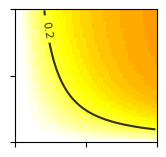

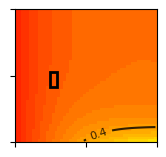

In [11]:
path_1_M_L = "figures/Fig_1/I(pol,hom)_M_L.pdf"
path_1_M_H = "figures/Fig_1/I(pol,hom)_M_H.pdf"
path_2_M = "figures/Fig_2/I(pol,hom,mean)_M.pdf"


fig_R_M_1_L = plot_multiple_metrics(
    res_list_M[0], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    #save_path=path_1_M_L
)
fig_R_M_1_H = plot_multiple_metrics(
    res_list_M[1], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    #save_path=path_1_M_H
)
fig_R_M_2 = plot_multiple_metrics(
    res_list_M[2], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M,
    #save_path=path_2_M
)

min-max range: 0.00040876865  to  0.30281472  -- max variation --  30.0
min-max range: 0.020692527  to  0.5310762  -- max variation --  51.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(


min-max range: 0.5373548  to  0.8097732  -- max variation --  27.0


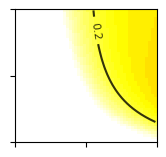

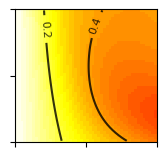

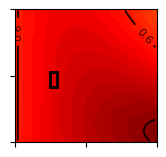

In [ ]:
path_1_M_L = "figures/Fig_1/I(pol,hom)_M_L.pdf"
path_1_M_H = "figures/Fig_1/I(pol,hom)_M_H.pdf"
path_2_M = "figures/Fig_2/I(pol,hom,mean)_M.pdf"


fig_R_M_1_L = plot_multiple_metrics(
    res_list_T[0], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    #save_path=path_1_M_L
)
fig_R_M_1_H = plot_multiple_metrics(
    res_list_T[1], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    #save_path=path_1_M_H
)
fig_R_M_2 = plot_multiple_metrics(
    res_list_T[2], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M,
    #save_path=path_2_M
)

min-max range: 0.0070670843  to  0.29135984  -- max variation --  28.0
min-max range: 0.16968381  to  0.4268521  -- max variation --  26.0
min-max range: 0.64896524  to  0.6986953  -- max variation --  5.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(


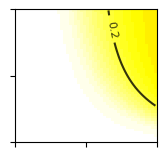

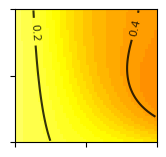

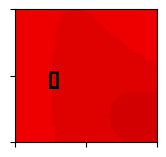

In [13]:
path_1_M_L = "figures/Fig_1/I(pol,hom)_M_L.pdf"
path_1_M_H = "figures/Fig_1/I(pol,hom)_M_H.pdf"
path_2_M = "figures/Fig_2/I(pol,hom,mean)_M.pdf"


fig_R_M_1_L = plot_multiple_metrics(
    res_list_V[0], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    #save_path=path_1_M_L
)
fig_R_M_1_H = plot_multiple_metrics(
    res_list_V[1], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T,
    #save_path=path_1_M_H
)
fig_R_M_2 = plot_multiple_metrics(
    res_list_V[2], 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M,
    #save_path=path_2_M
)

In [5]:
# plot all of them in one figure

def plot_25(res_list):
    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    for i, ax in enumerate(axes.flatten()):
        TI = np.sum(res_list[i]["final_state"]["I"] + res_list[i]["final_state"]["R"], axis=2)

        im = ax.imshow(
            TI, vmin = 0, vmax = 1, cmap = my_map,
            origin='lower', extent=[0, 1, 0, 6],
            aspect='auto')
        ax.set_title(f"{betas[i]:.3f}, TI in [{TI.min():.2f}, {TI.max():.2f}]")
        
        # Find minimum polarization for each homophily level
        min_pol_curve = []
        homophily_values = []
        
        for h_idx in range(TI.shape[0]):  # iterate over homophily axis (rows)
            # Find minimum polarization index for this homophily level
            pol_idx = np.nanargmin(TI[h_idx, :])
            
            # Convert indices to actual values
            min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (pol_idx / (pol_range["n"] - 1))
            homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (h_idx / (homophilic_tendency["n"] - 1))
            
            min_pol_curve.append(min_pol)
            homophily_values.append(homophily)
        
        # Plot the curve
        ax.plot(min_pol_curve, homophily_values, color="green", linewidth=1)
        print(min_pol_curve[-1])

    fig.tight_layout()

In [ ]:
print("### SIR-M ###")
PS = 20
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-T ###")
res_list_T = []

for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-V ###")
res_list_V = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4
### SIR-T ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M =

0.0
0.0
0.0
0.0
0.0
0.0
0.5714285714285714
0.5918367346938775
0.6122448979591837
0.6326530612244898
0.6530612244897959
0.6530612244897959
0.673469387755102
0.6938775510204082
0.6938775510204082
0.7142857142857143
0.7142857142857143
0.7346938775510204
0.7551020408163265
0.7551020408163265
0.7755102040816326
0.7755102040816326
0.7959183673469388
0.8163265306122449
0.8367346938775511
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.9795918367346939
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.7755102040816326
0.7551020408163265
0.7551020408163265
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.6938775510204082
0.6938775510204082
0.7142857142857143
0.7142857142857143
0.7142857142857143
0.7346938775510204
0.7346938775510204
0.7346938775510204
0.7346938775510204
0.7346938775510204
0.7551020408163265
0.7551020408163265


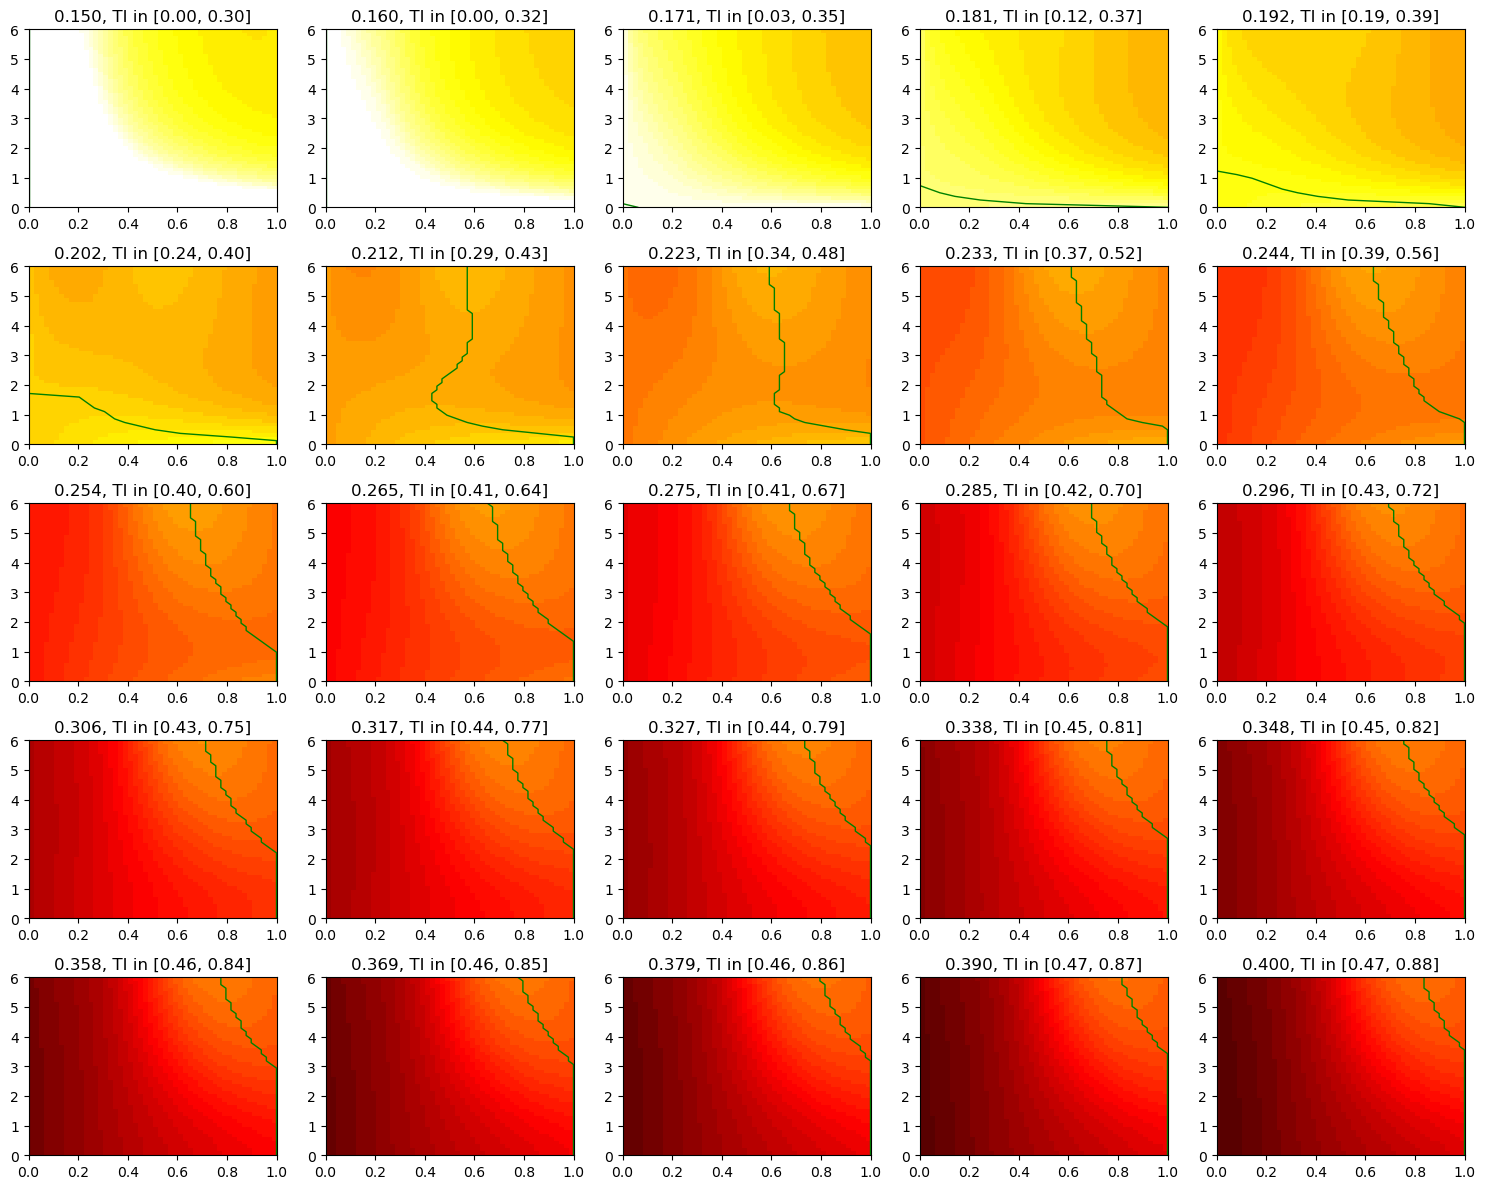

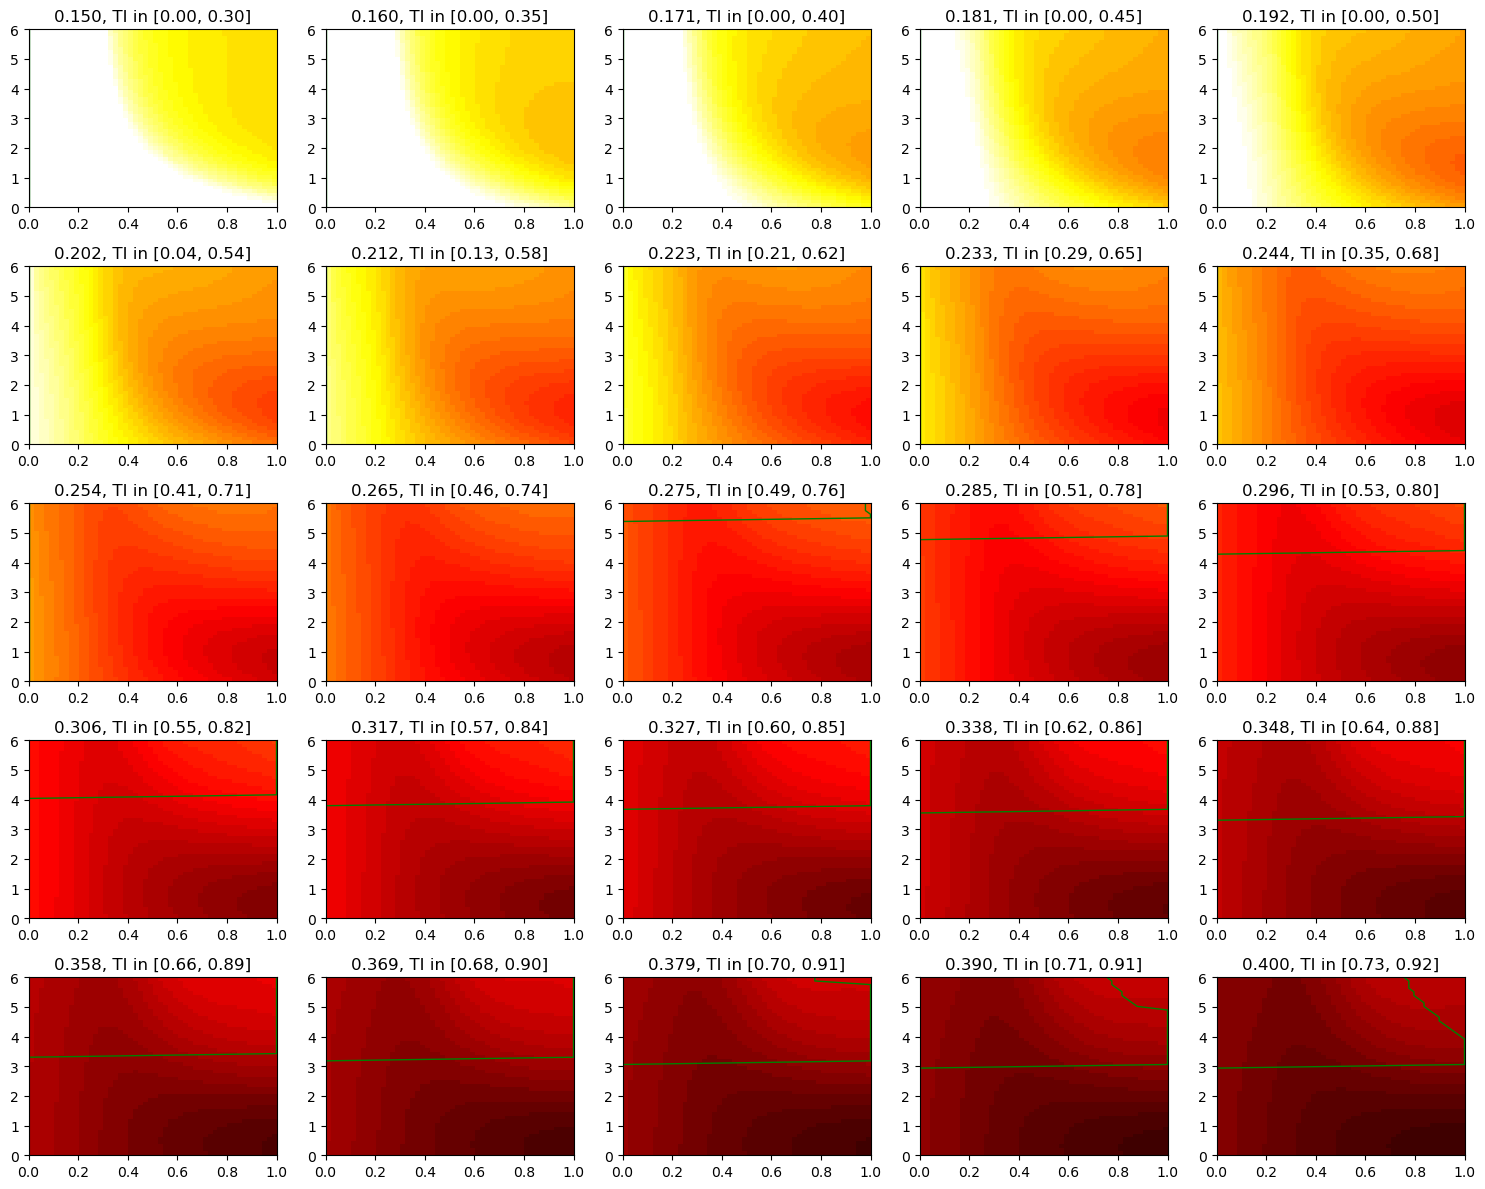

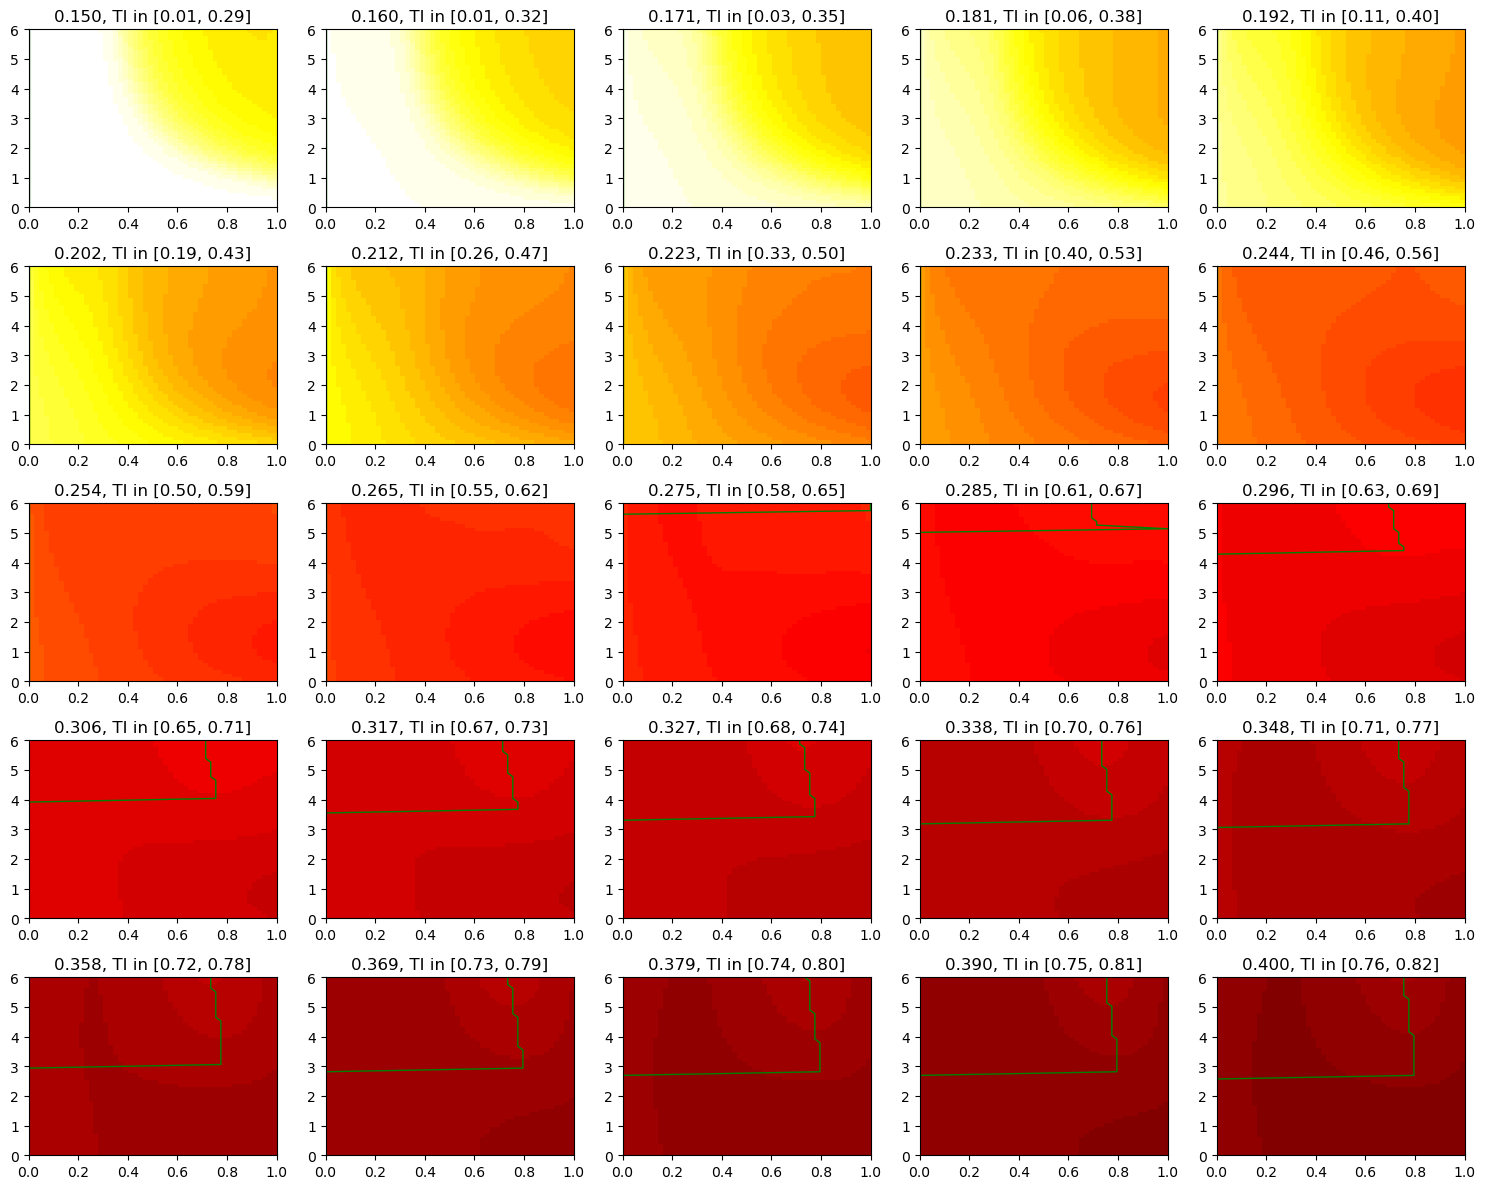

In [7]:
plot_25(res_list_M)
plot_25(res_list_T)
plot_25(res_list_V)

# Different_normalization


In [1]:
temp = read_json("./parameters.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]

print("### SIR-M ###")
PS = 20
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

NameError: name 'read_json' is not defined

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.4897959183673469
0.5102040816326531
0.5306122448979592
0.5306122448979592
0.5510204081632653
0.5714285714285714
0.5714285714285714
0.5714285714285714
0.5918367346938775
0.5918367346938775
0.5918367346938775
0.6122448979591837
0.6122448979591837
0.6122448979591837
0.6326530612244898
0.6326530612244898
0.6326530612244898
0.6326530612244898


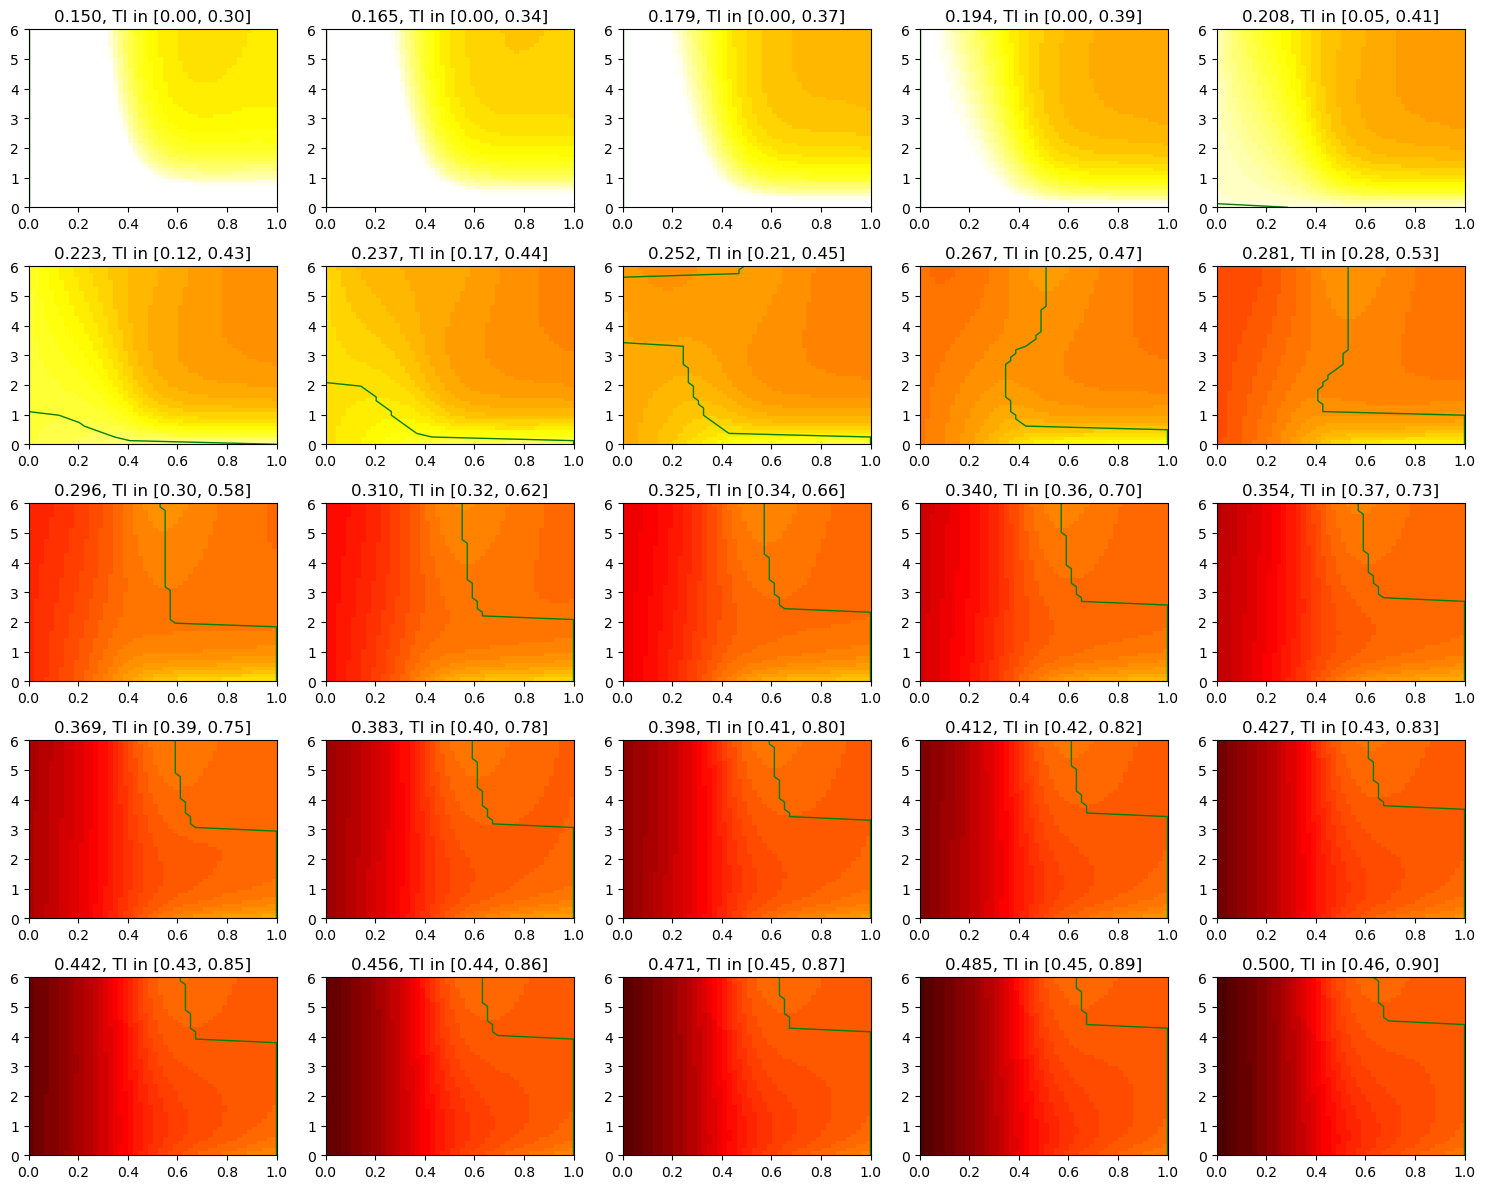

In [ ]:
plot_25(res_list_M)  

In [ ]:


print("### SIR-T ###")
res_list_T = []

for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_T.append(M)
    print(f"Completed beta_M = {b}")

print("### SIR-V ###")
res_list_V = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_V.append(M)
    print(f"Completed beta_M = {b}")

### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M = 0.18125
Completed beta_M = 0.19166666666666665
Completed beta_M = 0.20208333333333334
Completed beta_M = 0.2125
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.23333333333333334
Completed beta_M = 0.24375
Completed beta_M = 0.25416666666666665
Completed beta_M = 0.26458333333333334
Completed beta_M = 0.275
Completed beta_M = 0.28541666666666665
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.30625
Completed beta_M = 0.31666666666666665
Completed beta_M = 0.3270833333333333
Completed beta_M = 0.3375
Completed beta_M = 0.34791666666666665
Completed beta_M = 0.3583333333333333
Completed beta_M = 0.36875
Completed beta_M = 0.37916666666666665
Completed beta_M = 0.3895833333333333
Completed beta_M = 0.4
### SIR-T ###
Completed beta_M = 0.15
Completed beta_M = 0.16041666666666665
Completed beta_M = 0.17083333333333334
Completed beta_M =

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.4897959183673469
0.5102040816326531
0.5306122448979592
0.5306122448979592
0.5510204081632653
0.5714285714285714
0.5714285714285714
0.5714285714285714
0.5918367346938775
0.5918367346938775
0.5918367346938775
0.6122448979591837
0.6122448979591837
0.6122448979591837
0.6326530612244898
0.6326530612244898
0.6326530612244898
0.6326530612244898
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


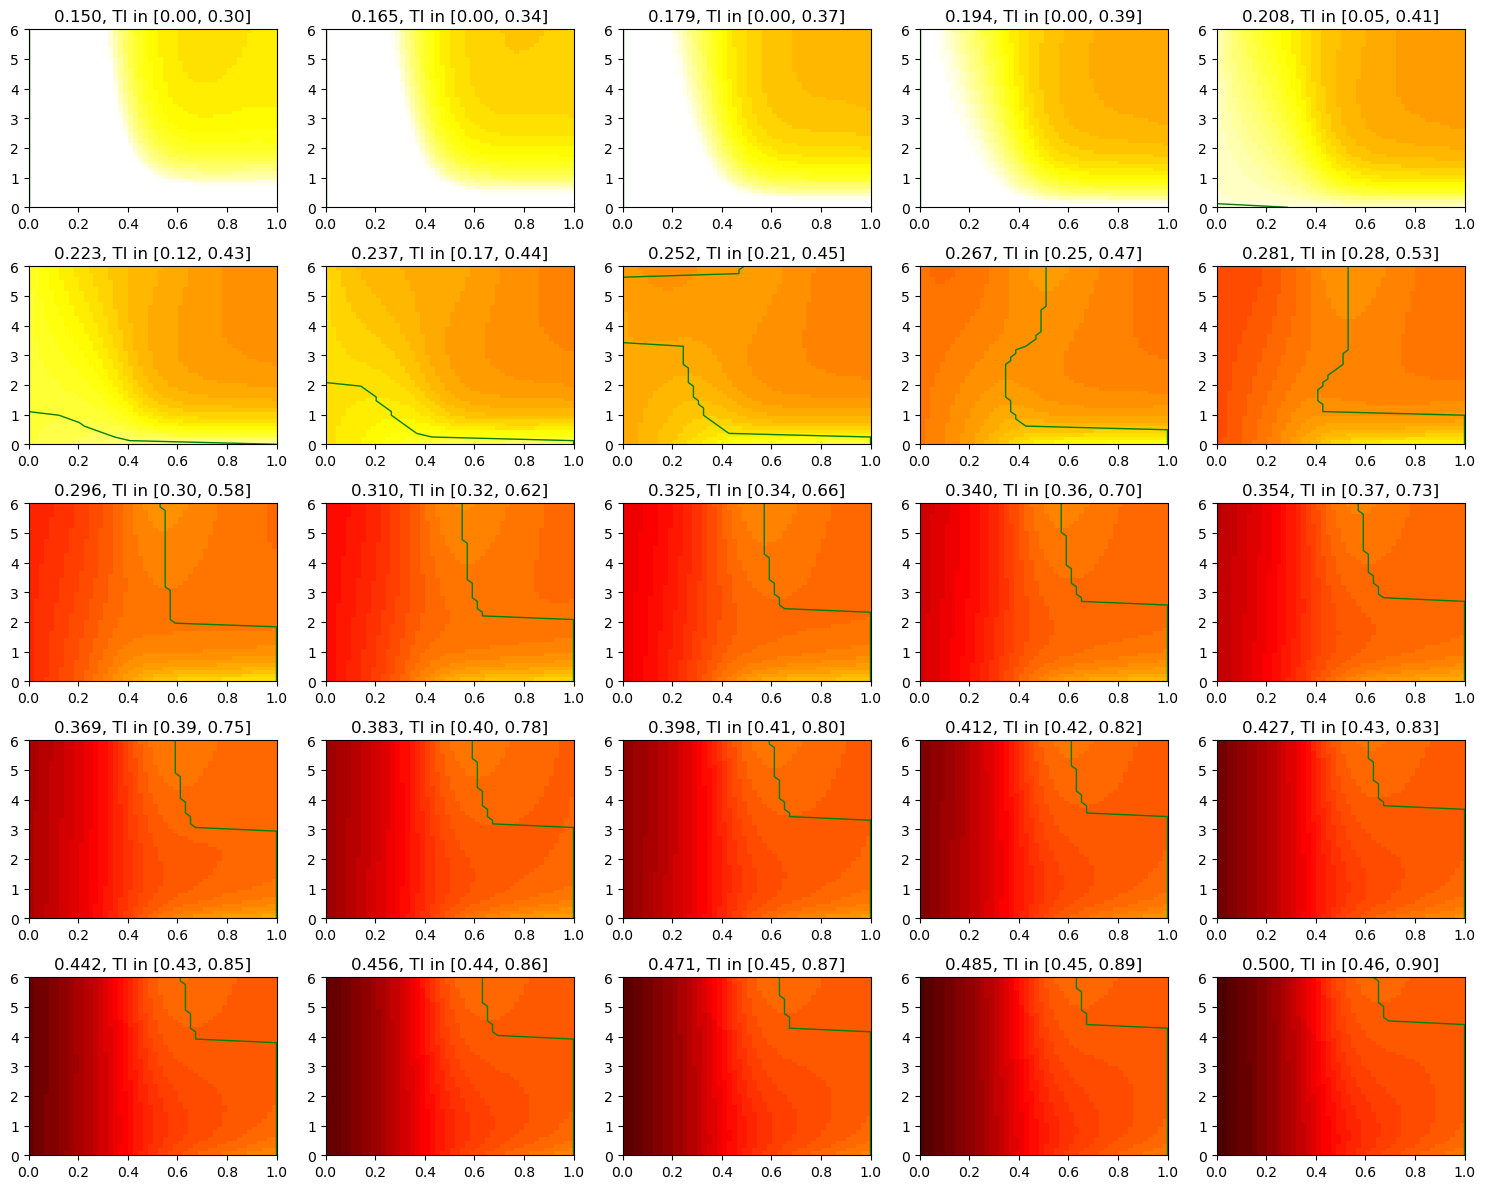

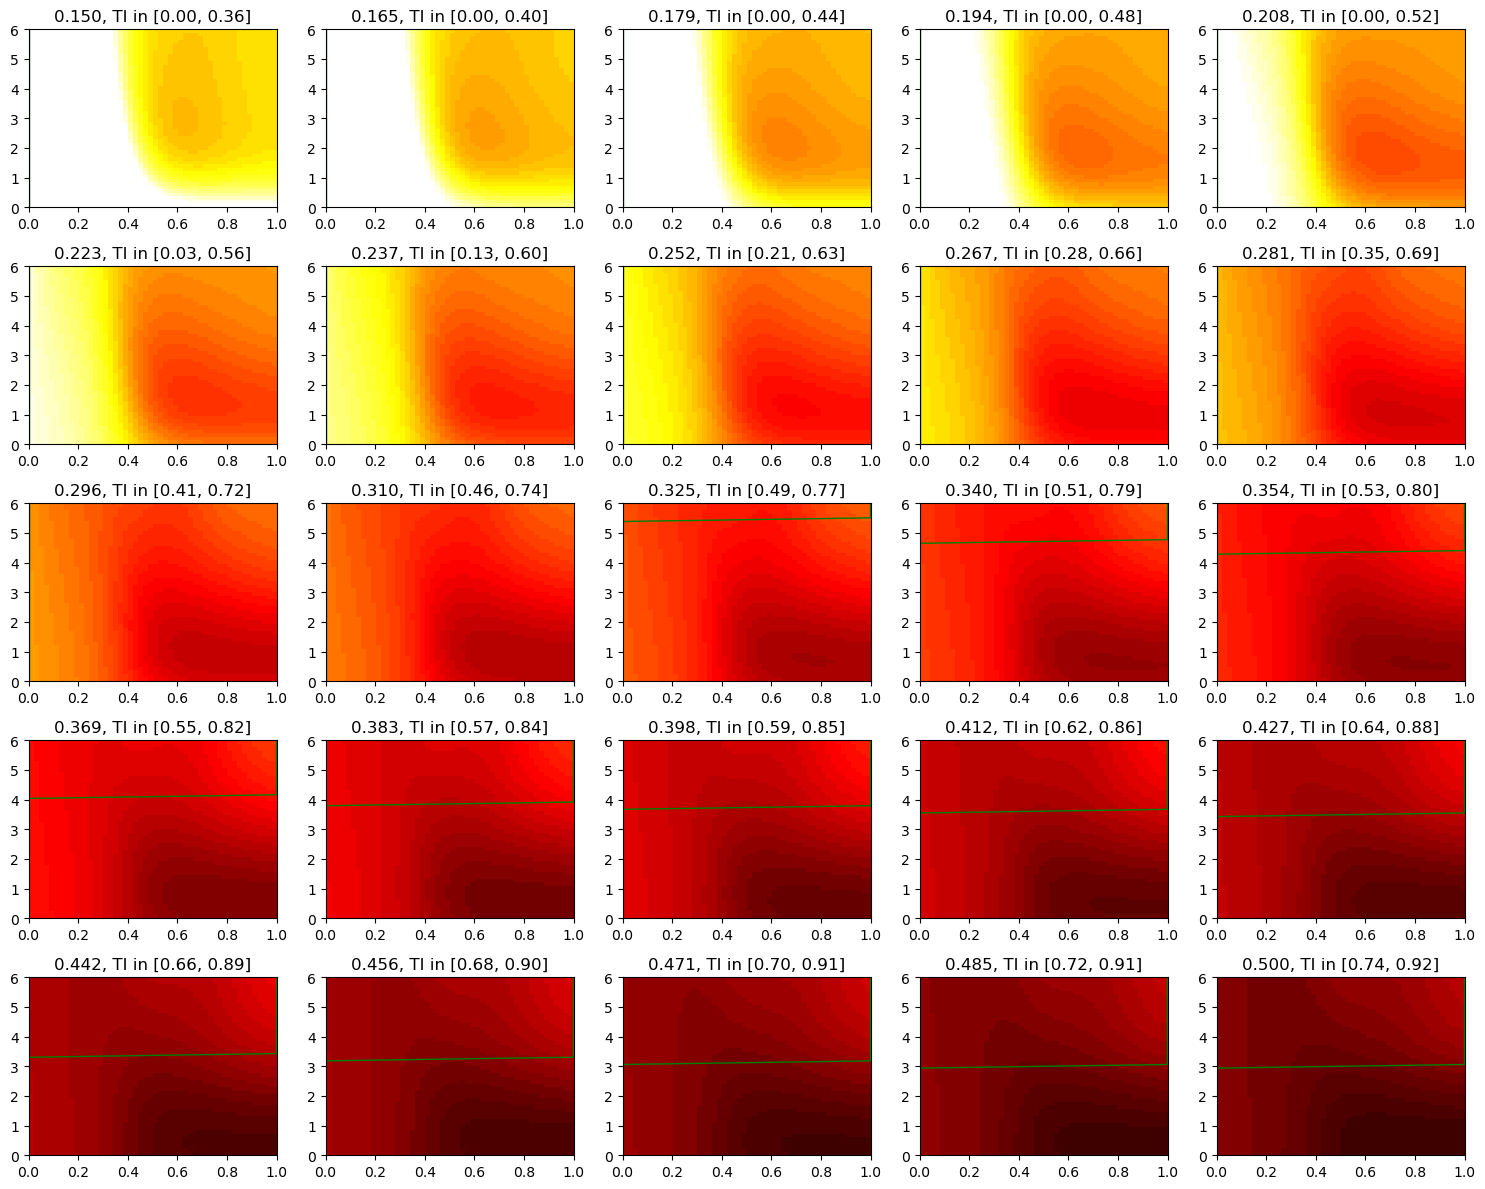

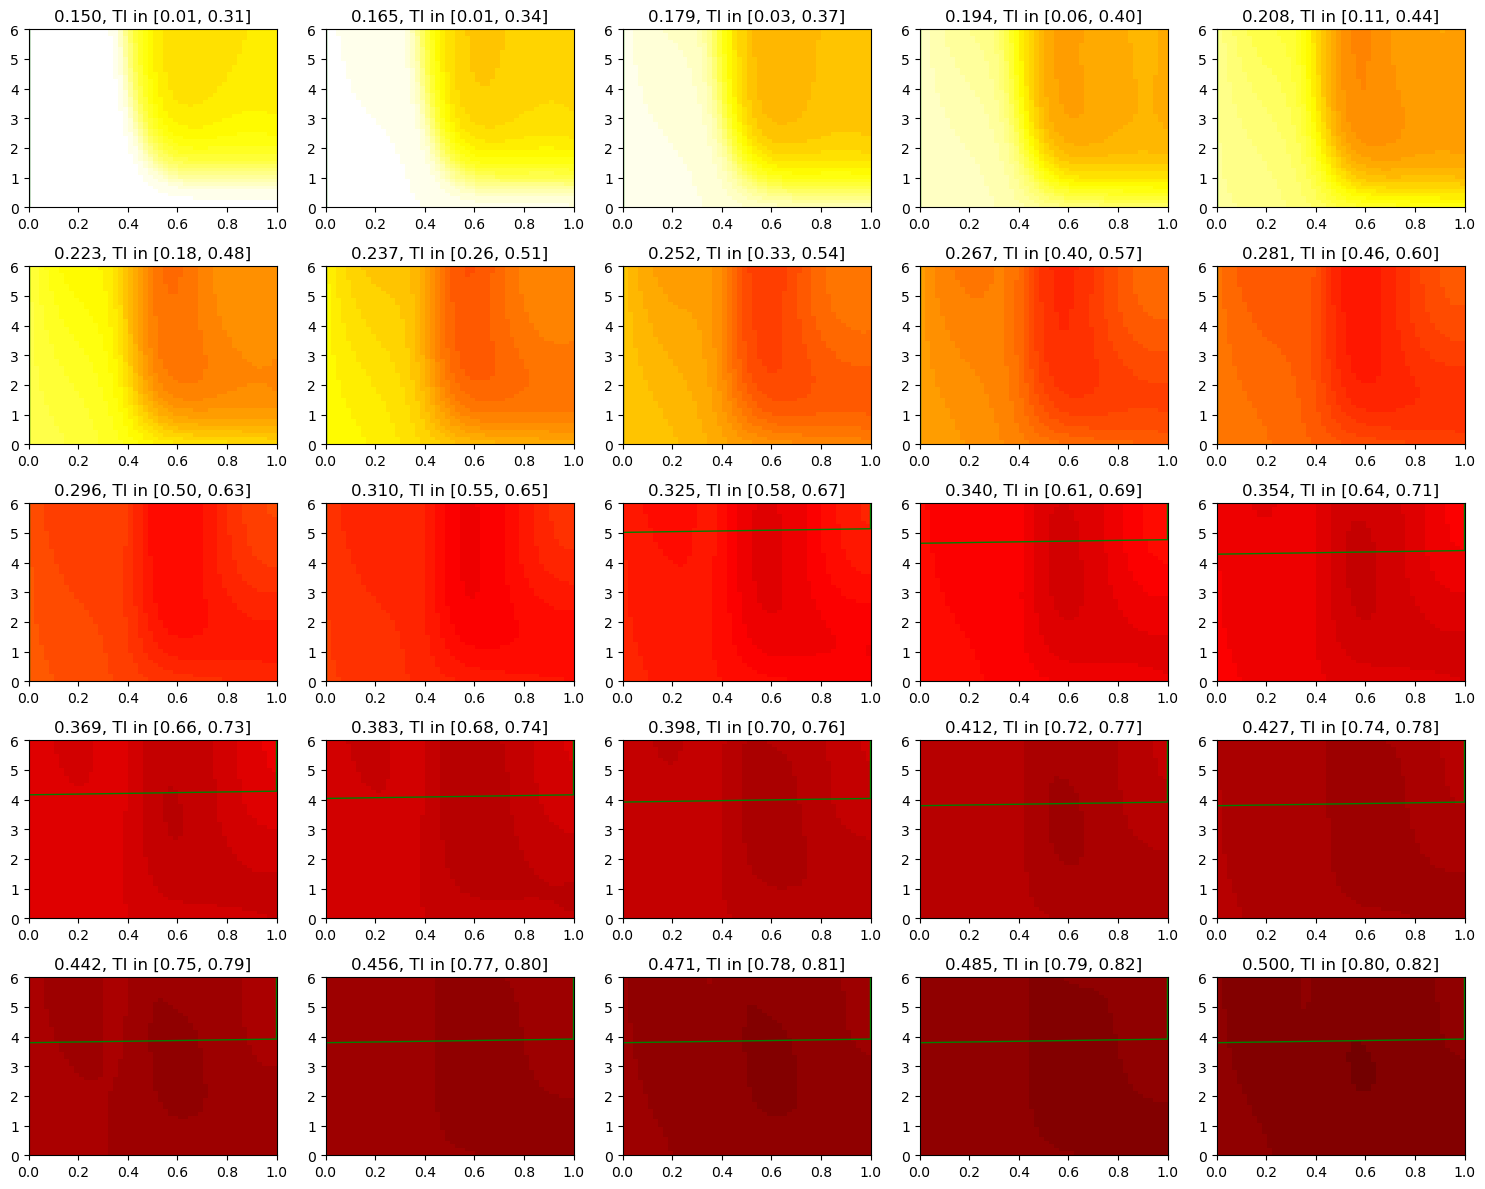

In [26]:
plot_25(res_list_M)
plot_25(res_list_T)
plot_25(res_list_V)

In [19]:
betas = np.linspace(0.15, 0.5, 25)
print("### SIR-M ###")
PS = 40
res_list_M = []
for b in betas:
    PARAMS["beta_M"] = b
    M = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2000
    )
    res_list_M.append(M)
    print(f"Completed beta_M = {b}")

### SIR-M ###
Completed beta_M = 0.15
Completed beta_M = 0.16458333333333333
Completed beta_M = 0.17916666666666667
Completed beta_M = 0.19374999999999998
Completed beta_M = 0.20833333333333331
Completed beta_M = 0.22291666666666665
Completed beta_M = 0.2375
Completed beta_M = 0.2520833333333333
Completed beta_M = 0.26666666666666666
Completed beta_M = 0.28125
Completed beta_M = 0.2958333333333333
Completed beta_M = 0.3104166666666667
Completed beta_M = 0.32499999999999996
Completed beta_M = 0.33958333333333335
Completed beta_M = 0.35416666666666663
Completed beta_M = 0.36874999999999997
Completed beta_M = 0.3833333333333333
Completed beta_M = 0.39791666666666664
Completed beta_M = 0.4125
Completed beta_M = 0.42708333333333326
Completed beta_M = 0.44166666666666665
Completed beta_M = 0.45624999999999993
Completed beta_M = 0.4708333333333333
Completed beta_M = 0.4854166666666666
Completed beta_M = 0.5


In [20]:
# plot all of them in one figure

def plot_25(res_list):
    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    for i, ax in enumerate(axes.flatten()):
        TI = np.sum(res_list[i]["final_state"]["I"] + res_list[i]["final_state"]["R"], axis=2)

        im = ax.imshow(
            TI, vmin = 0, vmax = 1, cmap = my_map,
            origin='lower', extent=[0, 1, 0, 6],
            aspect='auto')
        ax.set_title(f"{betas[i]:.3f}, TI in [{TI.min():.2f}, {TI.max():.2f}]")
        
        # Find minimum polarization for each homophily level
        min_pol_curve = []
        homophily_values = []
        
        for h_idx in range(TI.shape[0]):  # iterate over homophily axis (rows)
            # Find minimum polarization index for this homophily level
            pol_idx = np.nanargmin(TI[h_idx, :])
            
            # Convert indices to actual values
            min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (pol_idx / (pol_range["n"] - 1))
            homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (h_idx / (homophilic_tendency["n"] - 1))
            
            min_pol_curve.append(min_pol)
            homophily_values.append(homophily)
        
        # Plot the curve
        ax.plot(min_pol_curve, homophily_values, color="green", linewidth=1)
        print(min_pol_curve[-1])

    fig.tight_layout()

0.0
0.0
0.0
0.0
0.4897959183673469
0.5306122448979592
0.5510204081632653
0.5714285714285714
0.5714285714285714
0.5918367346938775
0.6122448979591837
0.6326530612244898
0.6530612244897959
0.673469387755102
0.6938775510204082
0.7346938775510204
0.7551020408163265
0.7959183673469388
1.0
1.0
1.0
1.0
1.0
1.0
1.0


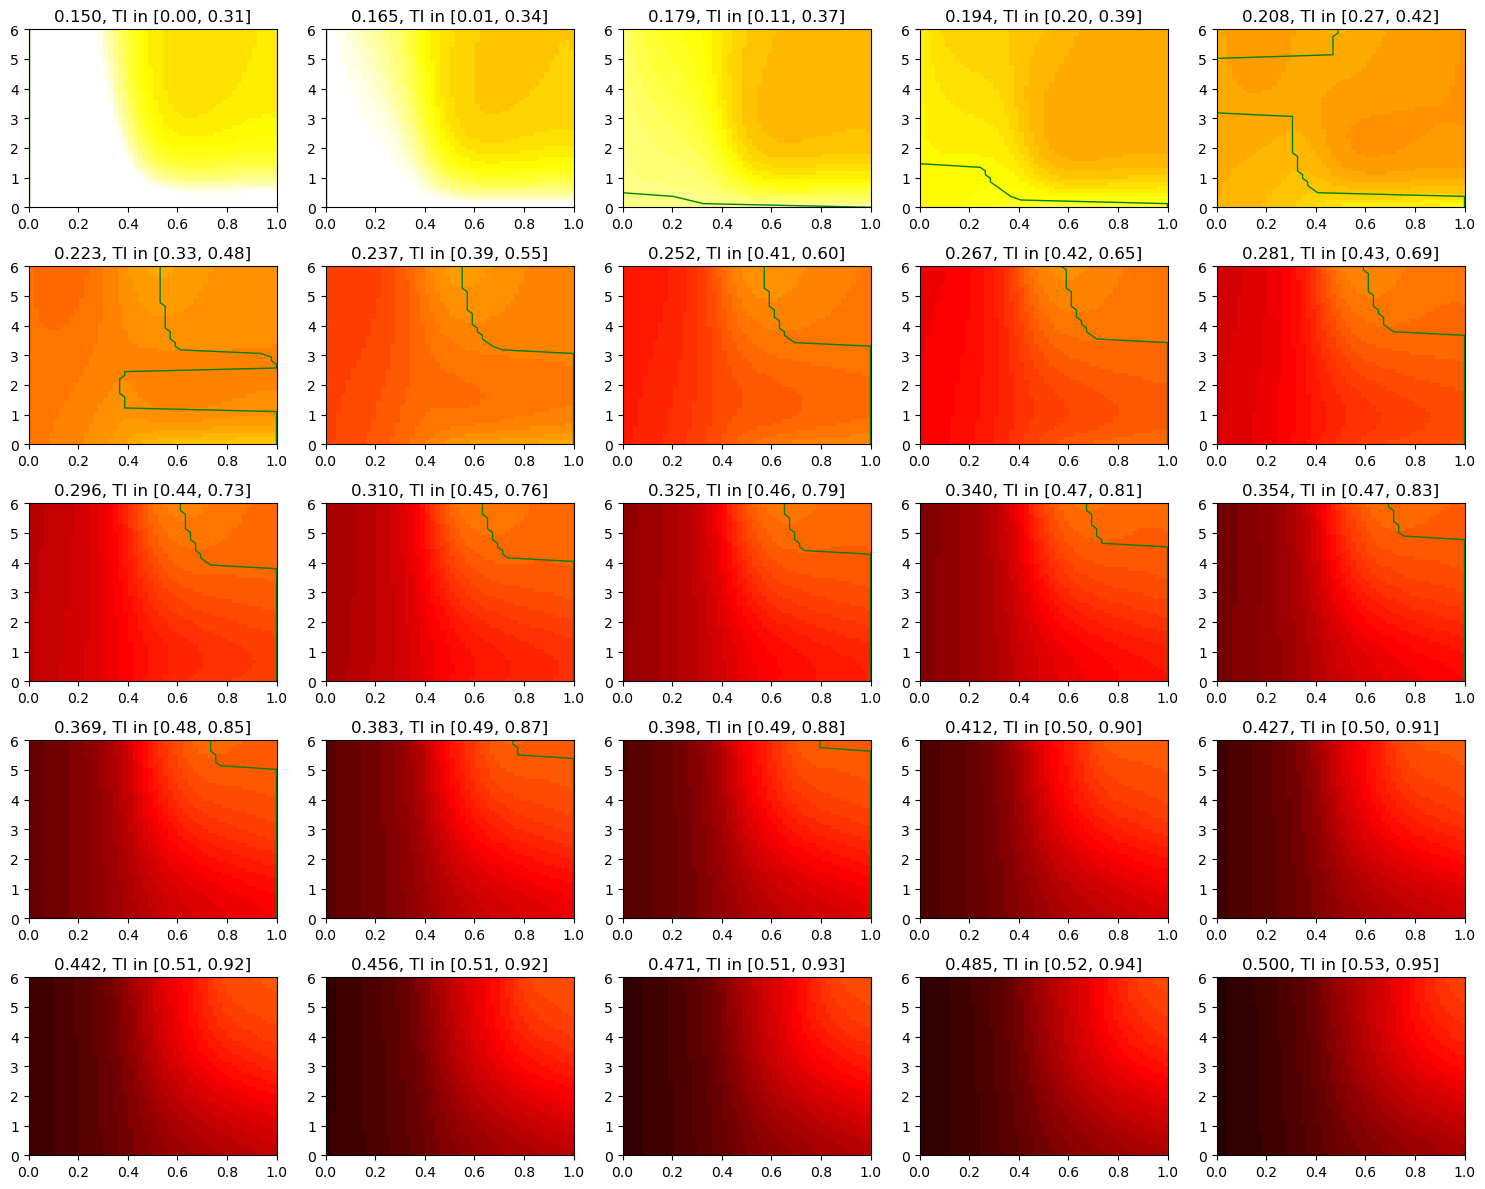

In [21]:
plot_25(res_list_M)

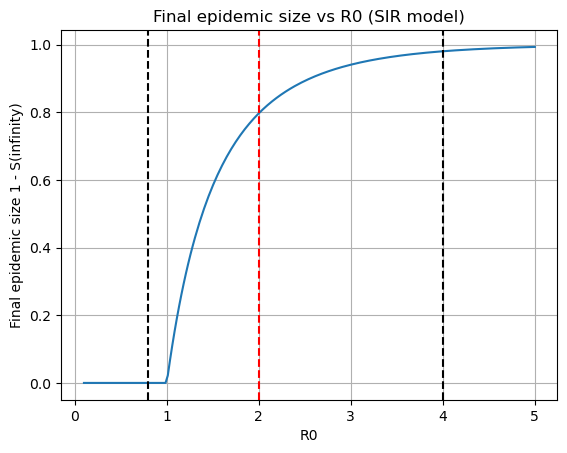

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def final_size(R0):
    # Solve S_inf = exp(-R0 * (1 - S_inf))
    func = lambda S: S - np.exp(-R0 * (1 - S))
    S_inf_guess = 0.1
    S_inf = fsolve(func, S_inf_guess)[0]
    return 1 - S_inf  # final epidemic size

R0_values = np.linspace(0.1, 5, 200)
final_sizes = [final_size(R0) for R0 in R0_values]

plt.plot(R0_values, final_sizes)

# plot a vertical line at R0 = 1
beta_M = 0.4/0.1
plt.axvline(x=beta_M/2,   color='red', linestyle='--')
plt.axvline(x=beta_M,     color='black', linestyle='--')
plt.axvline(x=beta_M*0.2, color='black', linestyle='--')
plt.xlabel("R0")
plt.ylabel("Final epidemic size 1 - S(infinity)")
plt.title("Final epidemic size vs R0 (SIR model)")
plt.grid(True)
plt.show()
